###**Business Case: Aerofit - Descriptive Statistics & Probability**

###**⬥ Problem Statement--Business Objective:**

**To analyze customer characteristics through given data and understand which factors influence the purchase of each of the Treadmill models - KP281, KP481 and KP781, in order to provide better recommendations for the New Treadmill Customers.**

 **It is achieved through following actions:**  
  **• Identify customer characteristics for each treadmill model (KP281, KP481, KP781)**   
  **• Compare differences across product categories**  
  **• Develop detailed customer profiles**  
  **• Calculate marginal and conditional probabilities**  
  **• Provide data-driven business recommendations**

###**1. Analyzing the data and basic metrics:**

####**1.1. Loading the Dataset**

In [50]:
# Load the dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
url="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/125/original/aerofit_treadmill.csv?1639992749"
data = pd.read_csv(url)
data.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


**✦ The Aerofit treadmill customer dataset is loaded directly from the provided online source using the Pandas library. The dataset contains customer demographic information and treadmill usage details, which will be analyzed to identify customer segments and derive business insights.**

####**1.2. Shape of the data:**

In [51]:
data.shape

(180, 9)

**✦ Aerofit data, which is related to the data of its specified models of treadmill customers of the past 3 months, has a total of 9 columns with attribute names as follows and a total of 180 rows.**

####**1.3. Data types of attributes:**

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


**✦ We have "Product" column specifying the type of treadmill, "Age" column mentioning the age of the customer, "Gender" column, "Education" column, "Marital Status" column, "Usage" column mentioning on average how many days a customer uses the treadmill per week, "Fitness" column where customers rate themselves from 1 to 5, "Income" of customers per year column, "Miles" column mentioning how many miles the customer may walk/run per week.**

####**1.4. Conversion of category attributes to category type:**

**✦ As each of the object type columns have repetitive values mostly, they can be converted into category type for memory efficiency and to improve processing speed.**

In [53]:
data['Product']=data['Product'].astype('category')
data['Gender']=data['Gender'].astype('category')
data['MaritalStatus']=data['MaritalStatus'].astype('category')

####**1.5. Null & Missing values check:**

In [54]:
data.isnull().sum()

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


**✦ We don't have any null values in the data.**

In [55]:
(data=="").sum()

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


**✦ We don't have any missing values in the data.**

####**1.6. Statistical Summary & Outlier check:**

In [56]:
data.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


**✦ This is the statistical summary of the given data (for the integer-type columns).**  
**✦ It is observed that for the variable 'Age', the mean is slightly higher than the median, indicating a slight right skew. The variable 'Education' appears slightly left-skewed. The variables 'Usage', 'Fitness', 'Income' and 'Miles' show slight right skewness. Overall, most variables exhibit mild skewness, but the minimum and maximum values appear reasonable and do not indicate obvious outliers or data errors.**

###**2. Exploratory Data Analysis (EDA)**

####**2.1. Unique values for each Attribute:**

In [57]:
data.nunique()

,0
Product,3
Age,32
Gender,2
Education,8
MaritalStatus,2
Usage,6
Fitness,5
Income,62
Miles,37


**✦ It is observed that we have only 3--"Product types", but many variations in "Age" ranging from 18 to 50, 2--"Gender types", 8--different "Education" levels ranging from 12 to 21, 2--"Marital Status" types, 6--"Usage" ways meaning the average number of days that customer may use the treadmill per week, 5--"Fitness" ratings from 1 to 5, several "Income" ranges from about 29,500 to 104,500 in dollars, multiple "Miles" values ranging from an average of 21 to 360 per week.**

####**2.2. Value counts for Categorical variable:**

In [58]:
data["Product"].value_counts()

,count
Product,
KP281,80
KP481,60
KP781,40


✦ **It is observed that most of the customers use KP281(entry-level model), followed by KP481(mid-level runners), followed by KP781(advanced model).**

In [59]:
data["Gender"].value_counts()

,count
Gender,
Male,104
Female,76


**✦ It is observed that the majority of the customers are "Male".**

In [60]:
data["MaritalStatus"].value_counts()

,count
MaritalStatus,
Partnered,107
Single,73


**✦ It is observed that the maximum number of customers are "Partnered".**

###**3. Exploratory Data Analysis – Visualizations**

####**3.1. Univariate analysis--Numerical data:**

####**3.1.1. Box plot -- Age attribute of customers data:**

Text(0.5, 1.0, 'Distribution of Customer Age')

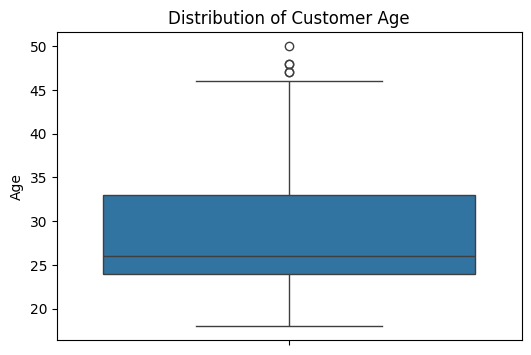

In [61]:
plt.figure(figsize=(6,4))
sns.boxplot(data["Age"])
plt.title("Distribution of Customer Age")

**✦ Age of customers extends between 18 and 50 but mostly lies between 25 to 33.**

####**Age outliers detection & treatment:**

In [62]:
q1, q3 = data['Age'].quantile([.25, .75])

In [63]:
age_outliers=data[(data["Age"]>q3+1.5*(q3-q1))|(data["Age"]<q1-1.5*(q3-q1))]["Age"]
print(age_outliers)

78     47
79     50
139    48
178    47
179    48
Name: Age, dtype: int64


**✦ Although a few observations under Age column are identified as statistical outliers, they reflect realistic age of customers and are not the result of data entry or measurement errors. Hence, they are not removed from the dataset.**

####**3.1.2. Box plot--Education:**

Text(0.5, 1.0, 'Distribution of Customer Education')

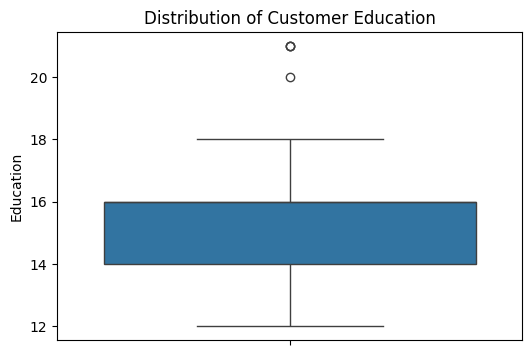

In [64]:
plt.figure(figsize=(6,4))
sns.boxplot(data["Education"])
plt.title("Distribution of Customer Education")

**✦ Educational years of customers ranges between 12 to 21, but mostly lies between 14 to 16.**

####**Education outliers detection and treatment:**

In [65]:
q1, q3 = data['Education'].quantile([.25, .75])
education_outliers=data[(data["Education"]>q3+1.5*(q3-q1))|(data["Education"]<q1-1.5*(q3-q1))]["Education"]
print(education_outliers)

156    20
157    21
161    21
175    21
Name: Education, dtype: int64


✦ **Although a few observations under Education column are identified as statistical outliers, they reflect realistic education levels of customers and are not the result of data entry or measurement errors. Hence, they are not removed from the dataset.**

####**3.1.3. Univariate analysis- Box plots for Usage, Fitness, Income and Miles (Numerical attributes)- Outliers detection & treatment:**

Text(0.5, 1.0, 'Distribution of Treadmill Usage')

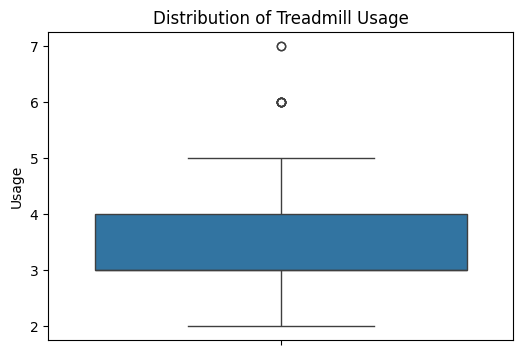

In [66]:
plt.figure(figsize=(6,4))
sns.boxplot(data["Usage"])
plt.title("Distribution of Treadmill Usage")

In [67]:
q1, q3 = data['Usage'].quantile([.25, .75])
usage_outliers=data[(data['Usage']>q3+1.5*(q3-q1))|(data['Usage']<q1-1.5*(q3-q1))]['Usage']
print(usage_outliers)

154    6
155    6
162    6
163    7
164    6
166    7
167    6
170    6
175    6
Name: Usage, dtype: int64


Text(0.5, 1.0, 'Distribution of Customer Fitness Levels')

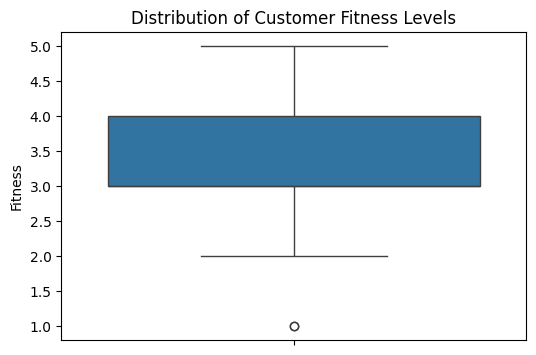

In [68]:
plt.figure(figsize=(6,4))
sns.boxplot(data["Fitness"])
plt.title("Distribution of Customer Fitness Levels")

In [69]:
q1, q3 = data['Fitness'].quantile([.25, .75])
fitness_outliers=data[(data['Fitness']>q3+1.5*(q3-q1))|(data['Fitness']<q1-1.5*(q3-q1))]['Fitness']
print(fitness_outliers)

14     1
117    1
Name: Fitness, dtype: int64


Text(0.5, 1.0, 'Distribution of Customer Income')

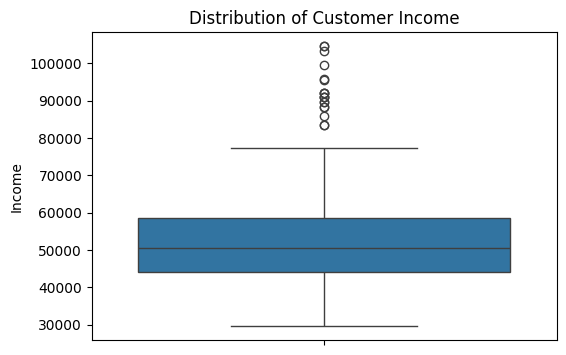

In [70]:
plt.figure(figsize=(6,4))
sns.boxplot(data["Income"])
plt.title("Distribution of Customer Income")

In [71]:
q1, q3 = data["Income"].quantile([.25, .75])
income_outliers=data[(data["Income"]>q3+1.5*(q3-q1))|(data["Income"]<q1-1.5*(q3-q1))]["Income"].sort_values(ascending=True)
print(income_outliers)

159     83416
175     83416
166     85906
164     88396
160     88396
170     89641
176     89641
167     90886
161     90886
177     90886
173     92131
162     92131
172     92131
179     95508
171     95866
169     99601
168    103336
174    104581
178    104581
Name: Income, dtype: int64


Text(0.5, 1.0, 'Distribution of Miles Run Per Week')

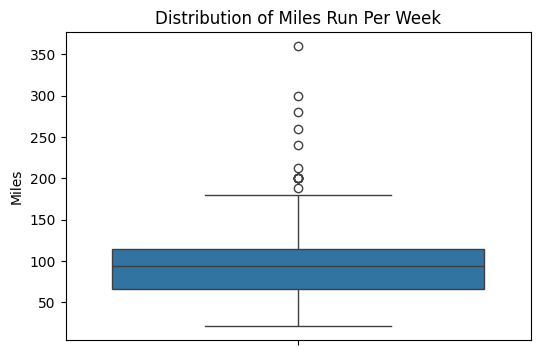

In [72]:
plt.figure(figsize=(6,4))
sns.boxplot(data["Miles"])
plt.title("Distribution of Miles Run Per Week")

In [73]:
q1, q3 = data["Miles"].quantile([.25, .75])
miles_outliers=data[(data["Miles"]>q3+1.5*(q3-q1))|(data["Miles"]<q1-1.5*(q3-q1))]["Miles"].sort_values(ascending=True)
print(miles_outliers)

23     188
142    200
148    200
152    200
175    200
176    200
171    200
84     212
155    240
170    260
167    280
166    300
173    360
Name: Miles, dtype: int64


####**✦ All the outliers observed are statistical outliers only but are realistic data of customers and not errors and hence are neither deleted nor replaced.**

####**3.1.4. Univariate analysis-Numerical data-Age distribution-Histogram:**

Text(0.5, 1.0, 'Histogram of Customer Age')

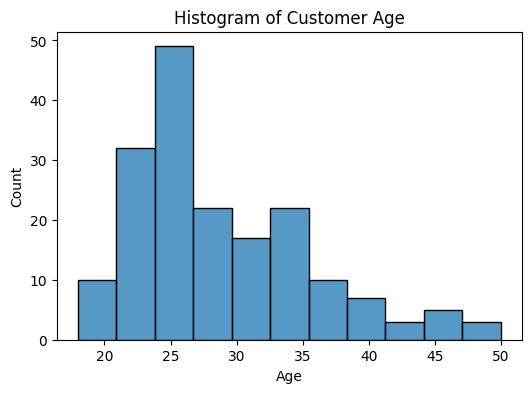

In [74]:
plt.figure(figsize=(6,4))
sns.histplot(x="Age",data=data)
plt.title("Histogram of Customer Age")

**✦ It is observed that majority of the customers of the given data are from approximately age bins: 24-27 followed by 21-24.**

####**3.2. Univariate analysis-Categorical data-Product-countplot:**

Text(0.5, 1.0, 'Product Purchase Distribution')

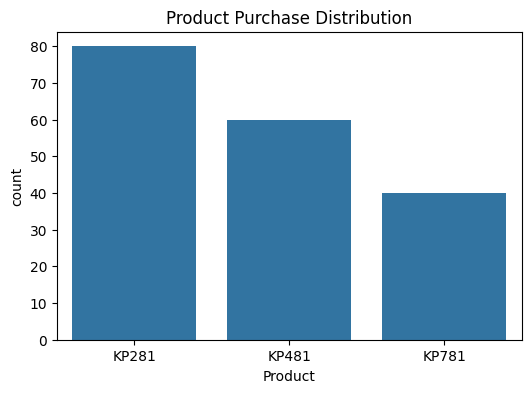

In [75]:
plt.figure(figsize=(6,4))
sns.countplot(x="Product",data=data)
plt.title("Product Purchase Distribution")

**✦ Through visual analysis it is evident that the maximum number of customers (about 80) are for the basic model KP281, followed by KP481 (about 60) and the fewest customers (about 40) are for the high-end model.**

####**3.3. Bivariate Analysis-Product(category) vs Numerical attributes:**

####**3.3.1. Product(cat) vs Income(num):**

Text(0.5, 1.0, 'Income Distribution by Product Model')

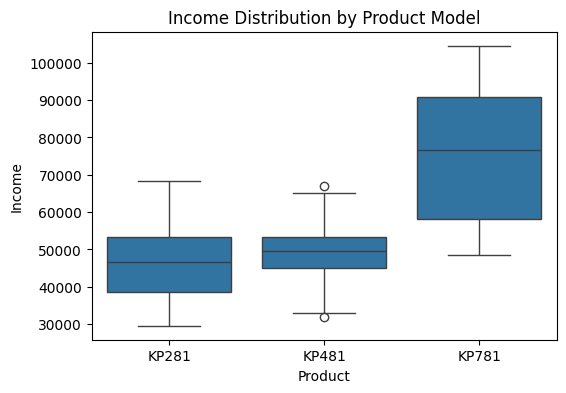

In [76]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Product",y="Income",data=data)
plt.title("Income Distribution by Product Model")

**✦ It is observed that lower model KP281 is preferred by low-income customers with income range from 30K to 70k, while mid-level model KP481 is preferred by income groups ranging between 35k to 65k and top-model KP781 is preferred mostly by high-income groups ranging from 48k to 150K.**

####**3.3.2. Product(cat) vs Fitness(num):**

Text(0.5, 1.0, 'Fitness Levels by Product Model')

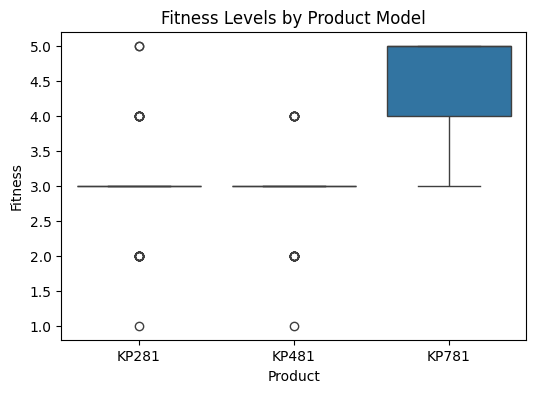

In [77]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Product",y="Fitness",data=data)
plt.title("Fitness Levels by Product Model")

**✦ From the above plot it is evident that the customers who buy basic model-KP281 mostly have fitness levels at 3 and very few between 1 to 5, customers of mid-level model KP481 also mostly have fitness levels at 3 and very few between 1 to 4 and customers of top-level model KP781 mostly have their fitness levels at 4 and 5 and very few have at 3. Thus, KP781 buyers are at highest fitness levels and the other 2 model buyers are at moderate fitness levels.**

####**3.3.3. Product(cat) vs Usage(num):**

Text(0.5, 1.0, 'Treadmill Usage by Product Model')

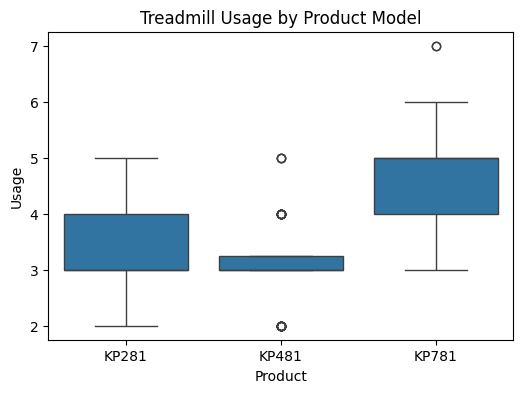

In [78]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Product",y="Usage",data=data)
plt.title("Treadmill Usage by Product Model")

**✦ It is observed that Premium treadmill buyers tend to use the treadmill more compared to the basic model treadmill buyers.**

####**3.4. Bivariate analysis- Product(category) vs Gender(category):**

Text(0.5, 1.0, 'Product Purchase by Gender')

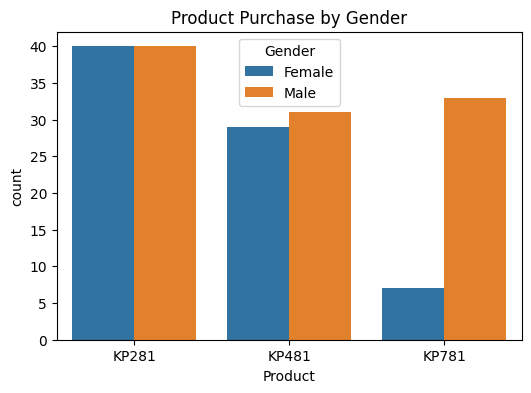

In [79]:
plt.figure(figsize=(6,4))
sns.countplot(x="Product",hue="Gender",data=data)
plt.legend(title='Gender',fontsize=10)
plt.title("Product Purchase by Gender")

**✦ It is evident from the plot that basic and mid-level models have almost equal number of customers from male and female groups, but high-end model KP781 has a majority of customers from the male group, i.e., about 33 male and about 8 female customers only.**

####**3.5. Correlation matrix:**

In [80]:
corr_matrix=data.corr(numeric_only=True)
corr_matrix

,Age,Education,Usage,Fitness,Income,Miles
Age,1.000000,0.280496,0.015064,0.061105,0.513414,0.036618
Education,0.280496,1.000000,0.395155,0.410581,0.625827,0.307284
Usage,0.015064,0.395155,1.000000,0.668606,0.519537,0.759130
Fitness,0.061105,0.410581,0.668606,1.000000,0.535005,0.785702
Income,0.513414,0.625827,0.519537,0.535005,1.000000,0.543473
Miles,0.036618,0.307284,0.759130,0.785702,0.543473,1.000000


####**3.5.1. Heat map:**

Text(0.5, 1.0, 'Correlation Matrix of Numerical Attributes')

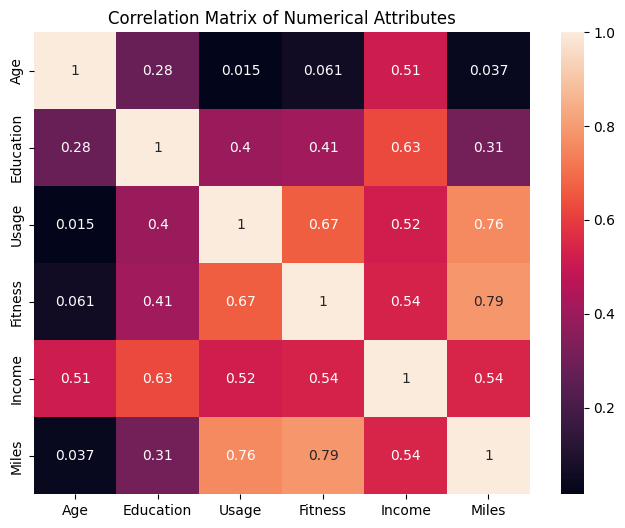

In [81]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True)
plt.title("Correlation Matrix of Numerical Attributes")

####**✦ Insights from Heat map:**  
• **Usage and miles** are **strongly positively correlated (0.76)**, suggesting that customers who use treadmill more frequently tend to cover greater running distances. Thus, people who use treadmill more frequently also run longer distances.   
• **Usage and fitness** are **moderately strong positive correlated (0.67)**, showing that customers with higher fitness level tend to use treadmill more frequently. Thus, fit customers exercise more regularly.  
• **Fitness is strongly related to both usage (0.67) and miles (0.79).**   
• **Income and education** also show a **moderately positive correlation (0.63)**, suggesting that customers with higher education levels tend to have higher income. This is a common real-world pattern.  
• **Income shows moderate positive correlation with usage, fitness and miles (0.52, 0.54, 0.54)**, indicating that customers with higher income tend to use treadmill more frequently, have better fitness levels and run longer distances.  
• **Age shows very weak correlation with most variables like usage, fitness and miles except for income** which is moderately positive correlated, indicating that treadmill usage behavior is not strongly influenced by customer's age, but income may increase with age.

**Overall, the heat map shows that customers who are more fit tend to use the treadmill more frequently and run greater distances. Income also shows moderate relation with usage and fitness, while age doesn't appear to influence treadmill usage patterns.**

####**3.5.2. Pair Plot**

Text(0.5, 1.02, 'Pair Plot of Numerical Attributes')

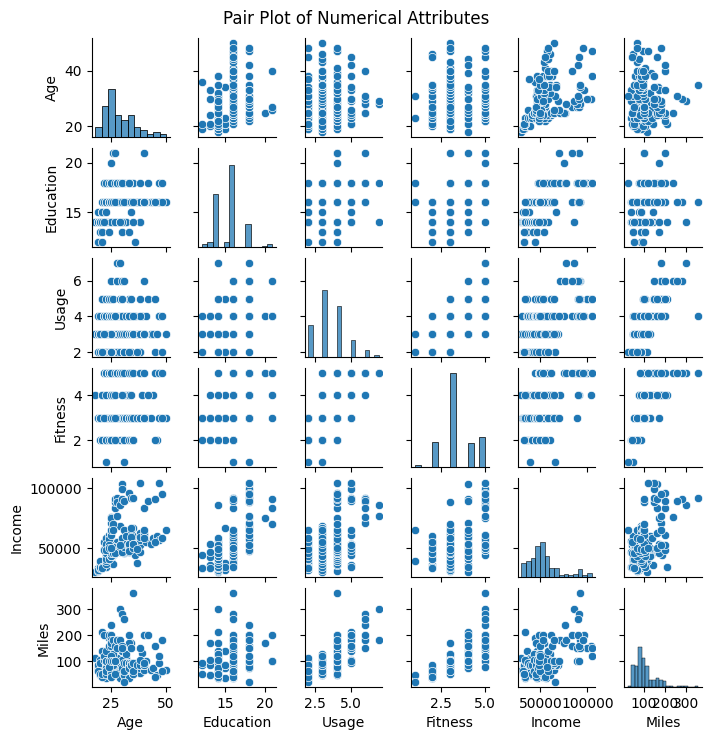

In [82]:
sns.pairplot(data,height=1.2)
plt.suptitle("Pair Plot of Numerical Attributes", y=1.02) # Add a main title for the pair plot

####**✦ Pair plot analysis:**  
• This pairplot provides **visual analysis between the numerical attributes/variables of the data.**  
• **A strong positive relationship** is observed between **Usage and Miles** indicating that customers who tend to use treadmill more frequently tend to walk/run longer distances.  
• **Fitness** also shows **positive relationship with miles and usage** implying that people with high fitness level are those who use the treadmill more frequently and cover longer distances.  
• **Income doesn't appear to have a strong relationship with fitness levels** **but treadmill usage or miles run seem to be slightly higher in case of high-income group people, implying that high-income groups comparatively use the treadmill more.**  
• **Age shows relatively weak relationship with most variables suggesting that treadmill usage patterns are not strongly dependent on age.**

####✦ **Pair plot Insights:**  
• **Customers who use treadmill more frequently, run more miles and have higher fitness levels.**  
• **People with higher fitness levels run more miles.**  
• **Higher-income customers tend to run more miles, use treadmill more frequently and have higher fitness levels.**  
• **Age and Education appear randomly scattered, implying they don't strongly influence treadmill usage or miles run.**

###**4. Customer Profiling & Segmentation**

####**4.1. Contingency Table-Product vs Gender:**

In [83]:
pd.crosstab(data["Product"],data["Gender"])

Gender,Female,Male
Product,,
KP281,40,40
KP481,29,31
KP781,7,33


####**4.2. Group statistics by Product:**

In [84]:
data.groupby("Product")[["Age","Income","Fitness","Miles","Usage"]].mean()

/tmp/ipykernel_1166/1202648615.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("Product")[["Age","Income","Fitness","Miles","Usage"]].mean()


,Age,Income,Fitness,Miles,Usage
Product,,,,,
KP281,28.55,46418.025,2.9625,82.787500,3.087500
KP481,28.90,48973.650,2.9000,87.933333,3.066667
KP781,29.10,75441.575,4.6250,166.900000,4.775000


**✦ It is observed that the basic models have almost equal number of customers across both the genders but the premium model treadmill has male customers in majority.**

**✦ From the above data it is seen that in case of the customers of KP281 treadmill:**  
▪Average income is lower(~ 46K)  
▪Fitness levels are moderate(~ 3)  
▪They run around 83 miles per week  
▪Use treadmill about 3 times weekly  
▪There are equal number of male and female customers but more partnered customers compared to single customers.

**✦ From the above data it is seen that in case of the customers of KP481 treadmill:**  
▪Average income is lower(~ 48K)  
▪Fitness levels are moderate(~ 3)  
▪They run around 88 miles per week  
▪Use treadmill about 3 times weekly  
▪There are almost equal number of male and female customers but more partnered customers compared to single customers.

**✦ From the above data it is seen that in case of the customers of KP781 treadmill:**  
▪Average income is higher(~ 75K)  
▪Fitness levels are very high(~ 4.6)  
▪They run around 167 miles per week  
▪Use treadmill about 4-5 times weekly  
▪There are high number of male customers (23) compared to female customers(17) but more partnered customers compared to single customers.

###**5. Probability Analysis:**

####**5.1. Marginal Probability-Probability of customers buying each of the treadmill models:**

In [85]:
data["Product"].value_counts(normalize=True)

,proportion
Product,
KP281,0.444444
KP481,0.333333
KP781,0.222222


**✦ Probability of customers buying KP281 (0.4) is very high, followed by KP481 (0.3) and then KP781 (0.2).**

####**5.2. Conditional probability--Probability of purchasing a particular model of treadmill provided the customer is Female and provided the customer is Male - P(Pr|F) & P(Pr|M) :**

In [86]:
pd.crosstab(data["Product"],data["Gender"],normalize="columns")

Gender,Female,Male
Product,,
KP281,0.526316,0.384615
KP481,0.381579,0.298077
KP781,0.092105,0.317308


**✦ It is clear that among female customers most prefer to buy KP281 (0.5), followed by KP481 (0.38) and least prefer KP781 (0.09). While among male customers most prefer KP281 (0.38), followed by almost the same amount of them who prefer KP781 (0.31), followed by KP481 (0.29).**

####**5.3. Conditional probability--Probability that which gender prefers it more, provided a particular model is bought - P(F|Pr) & P(M|Pr):**

In [87]:
pd.crosstab(data["Product"],data["Gender"],normalize="index")


Gender,Female,Male
Product,,
KP281,0.500000,0.500000
KP481,0.483333,0.516667
KP781,0.175000,0.825000


**✦ It is observed that basic model KP281 is preferred by both male and female customers equally, while mid-level model is preferred slightly more y male customers(51.6%) and slightly less by female customers(48.3%) and the premium model KP781 is highly preferred by male customers (82.5%) and very less preferred  by female customers (17.5%).**


###**6. Key Insights:**

**1. Range Insights:**
Age of customers ranges from young adults to middle-aged customers. Income varies significantly, with premium treadmill buyers belonging to higher income groups. Miles run per week shows large variation, indicating differences in customer fitness levels.   
**2. Distribution Insights:**
Income distribution is slightly right-skewed, indicating the presence of high-income customers. Fitness levels are mostly concentrated around moderate levels. Usage frequency is centered around 3-4 days per week.  
**3. Relationship Insights:**
Customers with higher fitness levels tend to run more miles & use treadmill more frequently. Higher-income customers are more likely to purchase premium treadmills. Usage frequency increases with fitness level and miles run.  
**4. Customer Profile Insights:**
Customers purchasing **premium treadmill** have **higher fitness levels**.  
**5**. **Premium treadmill** buyers use treadmill almost **4-5 days per week**.   
**6.** **Entry-level treadmills dominate overall sales**.  
**7. Age & Education have minimal impact on product choice.**  
**8. Premium treadmill purchases are predominantly male-driven.**

###**7. Business Recommendations:**
1. Target **high-income customer segments through premium marketing campaigns for KP781.**
2. Position **KP281 as an affordable entry-level treadmill for new fitness enthusiasts.**
3. Introduce **EMI plans** to encourage upgrades from KP281 to KP481.
4. Advertise **premium treadmills in fitness communities and gyms** to attract serious runners.
5. Launch **female-focused marketing campaigns** to increase premium treadmill sales among female customers.
6. **Bundle premium treadmills with fitness coaching & training programs**, to attract serious fitness enthusiasts, which most premium treadmill customers are, as per analysis.
7. Identify basic model customers who **frequently use their treadmills and run higher miles, and offer upgrade promotions or exchange offers for premium models**.
8. **Analyze customer fitness levels and treadmill usage patterns to recommend suitable treadmill models**, i.e., basic models for customers with lower fitness levels & less usage frequency and premium models for customers with higher fitness levels & high usage frequency.

### **8. Conclusion:**

✦ This analysis identified clear customer segments for Aerofit's three treadmill models. The premium model (KP781) primarily attracts high-income, highly active customers, while KP281 and KP481 appeal to a broader customer base. These insights can help Aerofit optimize product positioning, personalize marketing campaigns, and improve inventory planning.